<a href="https://colab.research.google.com/github/rsdina/IBM_HR_Analytics/blob/main/HR_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IBM HR Analytics Employee Attrition & Performance
This notebook provides a comprehensive HR Analytics project, covering data loading, cleaning, exploratory data analysis, predictive modeling, and results export.

Dataset: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

### Install and Import Libraries

This cell installs all the necessary Python libraries required for the project, including `kagglehub` for dataset download, `pandas` and `numpy` for data manipulation, `matplotlib` and `seaborn` for static visualizations, `scikit-learn` for machine learning, `xgboost` for advanced boosting models, `shap` for explainability, and `plotly` for interactive visualizations.

In [1]:
# Install required libraries
!pip install kagglehub
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap plotly

### Data Loading

This cell imports core libraries, sets visualization styles, and then proceeds to download the IBM HR Analytics Attrition dataset using `kagglehub`. It includes a fallback mechanism to download the dataset from a GitHub URL if the `kagglehub` download fails. Finally, it loads the data into a Pandas DataFrame `df` and displays the first 5 rows to provide a quick preview.

In [22]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Download dataset using kagglehub
print("Downloading dataset...")
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

# Find and load the CSV file
import os
csv_file = None
for file in os.listdir(path):
    if file.endswith('.csv'):
        csv_file = os.path.join(path, file)
        break

if csv_file:
    df = pd.read_csv(csv_file)
    print(f"Dataset loaded successfully! Shape: {df.shape}")
else:
    # Fallback to GitHub URL if kagglehub fails
    print("Falling back to GitHub URL...")
    url = 'https://raw.githubusercontent.com/NihalDhadse/ibm-hr/main/employee.csv'
    df = pd.read_csv(url)
    print(f"Dataset loaded successfully from GitHub! Shape: {df.shape}")

# Display first few rows
print("\nFirst 5 rows of the dataset:")
display(df.head())

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Dataset loaded successfully! Shape: (1470, 35)

First 5 rows of the dataset:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Dataset Overview

This cell provides a detailed overview of the loaded dataset. It prints:
- The total number of rows and columns.
- A list of all column names.
- The data types of each column.
- Basic descriptive statistics (count, mean, std, min, max, quartiles) for numerical columns.
- The number of unique values and value counts for the top entries in categorical columns.

In [3]:
# Dataset overview
print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print(f"\nNumber of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics for numerical columns:")
display(df.describe())

print("\nInformation about categorical columns:")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head())

DATASET OVERVIEW

Number of rows: 1470
Number of columns: 35

Column names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCoun

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000



Information about categorical columns:

Attrition: 2 unique values
Attrition
No     1233
Yes     237
Name: count, dtype: int64

BusinessTravel: 3 unique values
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Department: 3 unique values
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

EducationField: 6 unique values
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Name: count, dtype: int64

Gender: 2 unique values
Gender
Male      882
Female    588
Name: count, dtype: int64

JobRole: 9 unique values
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Name: count, dtype: int64

MaritalStatus: 3 unique values
MaritalStatus
Married     6

### Missing Values Analysis

This cell checks for the presence of missing values across all columns in the dataset. If any missing values are found, it creates a DataFrame showing the count and percentage of missing values per column and visualizes this information using a bar chart. If no missing values are present, it prints a confirmation message.

In [23]:
# Check for missing values
print("="*50)
print("MISSING VALUES ANALYSIS")
print("="*50)

missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Missing Values', ascending=False)

if len(missing_df) > 0:
    print(f"Total missing values: {df.isnull().sum().sum()}")
    print(f"Columns with missing values: {len(missing_df)}")
    display(missing_df)

    # Visualize missing values
    plt.figure(figsize=(12, 6))
    missing_df['Missing Values'].plot(kind='bar', color='coral')
    plt.title('Missing Values by Column', fontsize=16)
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(" No missing values found in the dataset!")

MISSING VALUES ANALYSIS
 No missing values found in the dataset!


### Data Cleaning

This cell performs essential data cleaning steps:
1.  **Handles Missing Values:** (Although the previous check indicated none, this section is prepared to fill numerical missing values with the median and categorical with the mode).
2.  **Converts Target Variable:** Transforms the 'Attrition' column ('Yes'/'No') into a binary numerical format ('Attrition_Binary': 1 for 'Yes', 0 for 'No') for model training.
3.  **Checks for Duplicates:** Identifies and removes any duplicate rows in the dataset.
4.  **Verifies Data Types:** Prints a summary of data types after cleaning to ensure correctness.
5.  **Summarizes Changes:** Reports the final shape of the cleaned dataset.

In [24]:
print("="*50)
print("DATA CLEANING")
print("="*50)

# Create a copy for cleaning
df_cleaned = df.copy()

# 1. Handle missing values (if any)
if df_cleaned.isnull().sum().sum() > 0:
    # For numerical columns, fill with median
    num_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        if df_cleaned[col].isnull().sum() > 0:
            median_val = df_cleaned[col].median()
            df_cleaned[col].fillna(median_val, inplace=True)

    # For categorical columns, fill with mode
    cat_cols = df_cleaned.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if df_cleaned[col].isnull().sum() > 0:
            mode_val = df_cleaned[col].mode()[0]
            df_cleaned[col].fillna(mode_val, inplace=True)

    print(" Missing values handled successfully!")

# 2. Convert 'Attrition' to binary numeric for analysis
df_cleaned['Attrition_Binary'] = df_cleaned['Attrition'].map({'Yes': 1, 'No': 0})

# 3. Check for duplicates
duplicates = df_cleaned.duplicated().sum()
if duplicates > 0:
    df_cleaned.drop_duplicates(inplace=True)
    print(f" Removed {duplicates} duplicate rows")
else:
    print(" No duplicate rows found")

# 4. Verify data types
print("\nData types after cleaning:")
print(df_cleaned.dtypes.value_counts())

# 5. Summary after cleaning
print(f"\n Final dataset shape: {df_cleaned.shape}")

DATA CLEANING
 No duplicate rows found

Data types after cleaning:
int64     27
object     9
Name: count, dtype: int64

 Final dataset shape: (1470, 36)


### Exploratory Data Analysis: Attrition Distribution

This cell visualizes the distribution of employee attrition within the dataset. It generates an interactive Plotly subplot with two charts:
-   A **bar chart** showing the count of employees who stayed and left.
-   A **pie chart** showing the percentage distribution of attrition.

It also calculates and prints the overall attrition rate, along with the absolute counts of employees who stayed and left.

In [7]:
print("="*50)
print("EXPLORATORY DATA ANALYSIS")
print("="*50)

# 1. Attrition Distribution
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Attrition Count', 'Attrition Percentage'),
                    specs=[[{"type": "bar"}, {"type": "domain"}]]) # Specify subplot types

# Count plot
attrition_counts = df_cleaned['Attrition'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']

fig.add_trace(
    go.Bar(x=attrition_counts.index, y=attrition_counts.values,
           marker_color=colors, text=attrition_counts.values, textposition='outside'),
    row=1, col=1
)

# Pie chart
fig.add_trace(
    go.Pie(labels=attrition_counts.index, values=attrition_counts.values,
           hole=0.3, marker_colors=colors),
    row=1, col=2
)

fig.update_layout(height=400, width=1000, showlegend=False, title_text="Attrition Distribution")
fig.show()

# Print statistics
attrition_rate = (df_cleaned['Attrition_Binary'].sum() / len(df_cleaned)) * 100
print(f"Overall Attrition Rate: {attrition_rate:.2f}%")
print(f"Employees Stayed: {attrition_counts['No']:,}")
print(f"Employees Left: {attrition_counts['Yes']:,}")

EXPLORATORY DATA ANALYSIS


Overall Attrition Rate: 16.12%
Employees Stayed: 1,233
Employees Left: 237


### Exploratory Data Analysis: Demographic Visualizations

This cell explores attrition patterns across various demographic features using interactive Plotly charts. It generates subplots for:
-   **Age Distribution:** Overlaid histograms showing age distribution for employees who stayed and left.
-   **Gender Distribution:** Bar chart showing the count of male and female employees.
-   **Marital Status Distribution:** Bar chart displaying counts for different marital statuses.
-   **Education Field Distribution:** Bar chart for the top education fields.
-   **Department Distribution:** Bar chart showing employee counts per department.
-   **Job Role Distribution:** Bar chart for the top job roles.

In [8]:
# Demographic visualizations
fig = make_subplots(rows=2, cols=3,
                    subplot_titles=['Age Distribution', 'Gender Distribution',
                                  'Marital Status', 'Education Field',
                                  'Department Distribution', 'Job Role Distribution'])

# 1. Age Distribution with Attrition overlay
fig.add_trace(
    go.Histogram(x=df_cleaned[df_cleaned['Attrition']=='Yes']['Age'],
                 name='Attrition=Yes', opacity=0.7, marker_color='red'),
    row=1, col=1
)
fig.add_trace(
    go.Histogram(x=df_cleaned[df_cleaned['Attrition']=='No']['Age'],
                 name='Attrition=No', opacity=0.7, marker_color='green'),
    row=1, col=1
)

# 2. Gender Distribution
gender_counts = df_cleaned['Gender'].value_counts()
fig.add_trace(
    go.Bar(x=gender_counts.index, y=gender_counts.values, marker_color=['#3498db', '#e74c3c']),
    row=1, col=2
)

# 3. Marital Status
marital_counts = df_cleaned['MaritalStatus'].value_counts()
fig.add_trace(
    go.Bar(x=marital_counts.index, y=marital_counts.values, marker_color=['#2ecc71', '#f39c12', '#9b59b6']),
    row=1, col=3
)

# 4. Education Field
edu_counts = df_cleaned['EducationField'].value_counts().head()
fig.add_trace(
    go.Bar(x=edu_counts.index, y=edu_counts.values, marker_color='#1abc9c'),
    row=2, col=1
)

# 5. Department Distribution
dept_counts = df_cleaned['Department'].value_counts()
fig.add_trace(
    go.Bar(x=dept_counts.index, y=dept_counts.values, marker_color=['#e67e22', '#3498db', '#2ecc71']),
    row=2, col=2
)

# 6. Job Role Distribution
job_counts = df_cleaned['JobRole'].value_counts().head()
fig.add_trace(
    go.Bar(x=job_counts.index, y=job_counts.values, marker_color='#e74c3c'),
    row=2, col=3
)

fig.update_layout(height=800, width=1200, showlegend=False, title_text="Demographic Analysis")
fig.show()

### Exploratory Data Analysis: Compensation and Performance Analysis

This cell analyzes the relationship between compensation, job performance, and attrition. It generates interactive Plotly subplots for:
-   **Monthly Income by Attrition:** Box plots comparing monthly income for employees who stayed versus those who left.
-   **Hourly Rate Distribution:** Histogram showing the distribution of hourly rates.
-   **Job Satisfaction by Attrition:** Box plots comparing job satisfaction levels.
-   **Performance Rating by Attrition:** Box plots comparing performance ratings.

Additionally, it performs a **T-test** to statistically determine if there's a significant difference in monthly income between employees who left and those who stayed.

In [25]:
# Salary and compensation visualizations
fig = make_subplots(rows=2, cols=2,
                    subplot_titles=['Monthly Income by Attrition',
                                  'Hourly Rate Distribution',
                                  'Job Satisfaction by Attrition',
                                  'Performance Rating by Attrition'])

# 1. Monthly Income Box Plot
fig.add_trace(
    go.Box(y=df_cleaned[df_cleaned['Attrition']=='Yes']['MonthlyIncome'],
           name='Attrition=Yes', marker_color='red', boxmean=True),
    row=1, col=1
)
fig.add_trace(
    go.Box(y=df_cleaned[df_cleaned['Attrition']=='No']['MonthlyIncome'],
           name='Attrition=No', marker_color='green', boxmean=True),
    row=1, col=1
)

# 2. Hourly Rate Distribution
fig.add_trace(
    go.Histogram(x=df_cleaned['HourlyRate'], nbinsx=30,
                 marker_color='blue', opacity=0.7),
    row=1, col=2
)

# 3. Job Satisfaction Box Plot
fig.add_trace(
    go.Box(y=df_cleaned[df_cleaned['Attrition']=='Yes']['JobSatisfaction'],
           name='Attrition=Yes', marker_color='#FF6B6B', boxmean=True),
    row=2, col=1
)
fig.add_trace(
    go.Box(y=df_cleaned[df_cleaned['Attrition']=='No']['JobSatisfaction'],
           name='Attrition=No', marker_color='#4ECDC4', boxmean=True),
    row=2, col=1
)

# 4. Performance Rating Box Plot
fig.add_trace(
    go.Box(y=df_cleaned[df_cleaned['Attrition']=='Yes']['PerformanceRating'],
           name='Attrition=Yes', marker_color='#FF6B6B', boxmean=True),
    row=2, col=2
)
fig.add_trace(
    go.Box(y=df_cleaned[df_cleaned['Attrition']=='No']['PerformanceRating'],
           name='Attrition=No', marker_color='#4ECDC4', boxmean=True),
    row=2, col=2
)

fig.update_layout(height=800, width=1000, title_text="Compensation and Performance Analysis")
fig.show()

# Statistical tests
from scipy import stats

# Check if attrition groups differ significantly in income
income_yes = df_cleaned[df_cleaned['Attrition']=='Yes']['MonthlyIncome']
income_no = df_cleaned[df_cleaned['Attrition']=='No']['MonthlyIncome']
t_stat, p_value = stats.ttest_ind(income_yes, income_no)
print(f"Monthly Income - T-test p-value: {p_value:.4f}")
print(f"Significant difference: {' Yes' if p_value < 0.05 else ' No'}")

Monthly Income - T-test p-value: 0.0000
Significant difference:  Yes


### Correlation Analysis

This cell performs a correlation analysis on the numerical features of the dataset.
-   It calculates the **Pearson correlation matrix** for selected numerical columns.
-   It visualizes this correlation matrix using a **heatmap** from `seaborn`, making it easy to identify relationships between variables.
-   It also identifies and prints the **top 10 features most correlated with 'Attrition_Binary'**, providing insights into potential drivers of attrition.

CORRELATION ANALYSIS


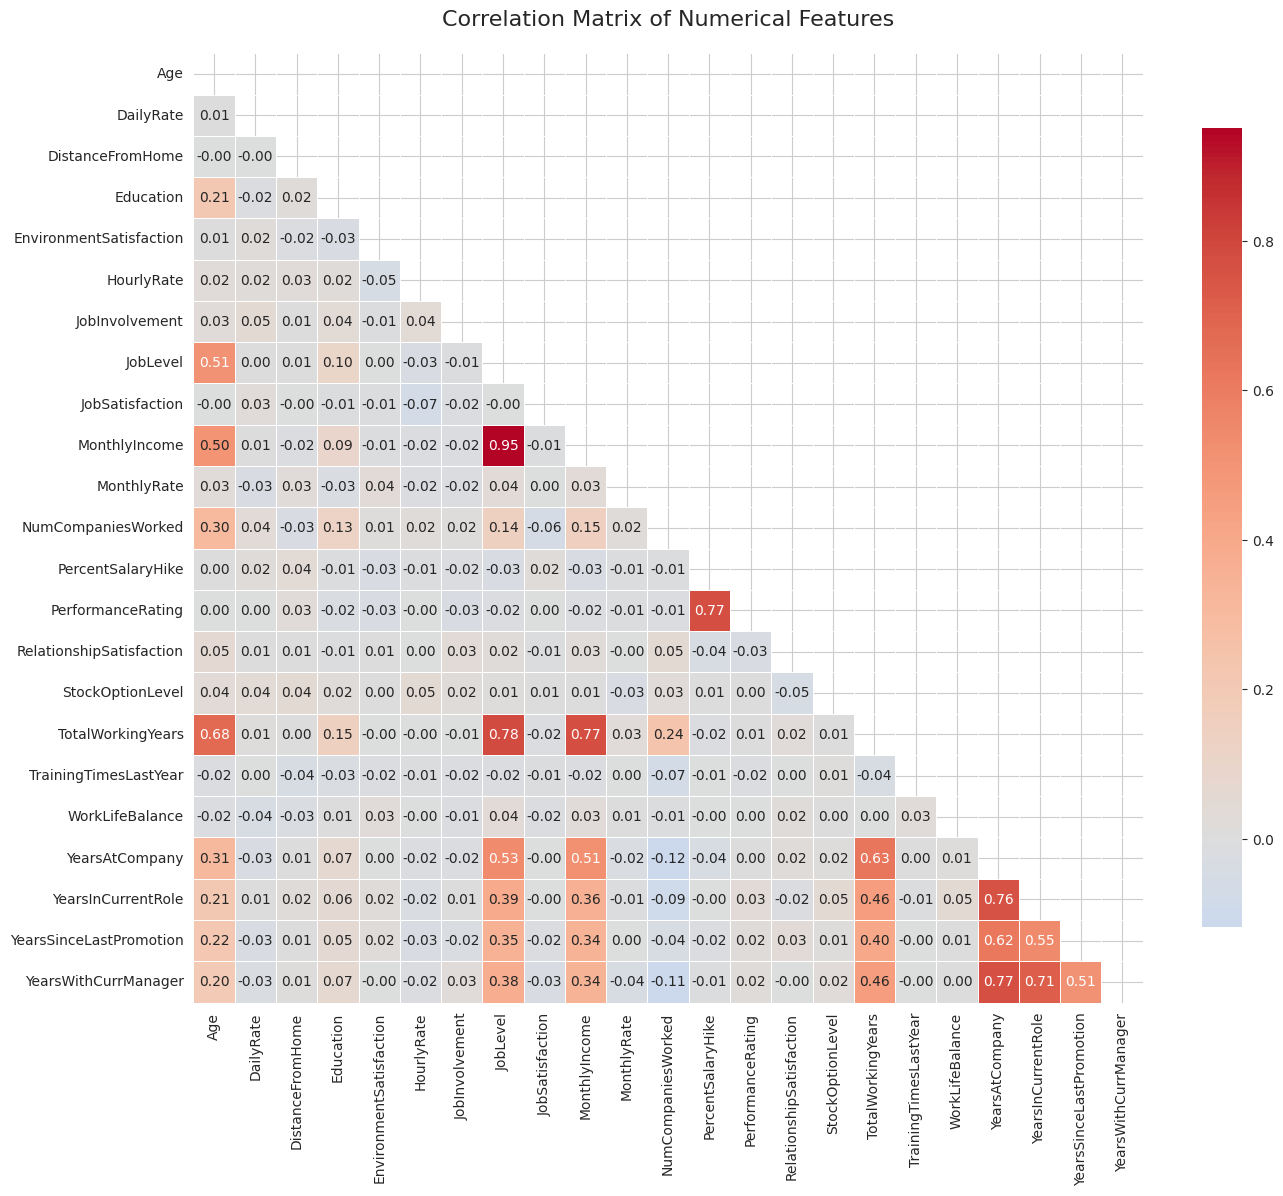


Top 10 Features Correlated with Attrition:
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652


In [11]:
# Correlation analysis
print("="*50)
print("CORRELATION ANALYSIS")
print("="*50)

# Select numerical columns
num_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
# Remove ID columns and binary target
num_cols = [col for col in num_cols if col not in ['EmployeeCount', 'EmployeeNumber',
                                                   'StandardHours', 'Over18', 'Attrition_Binary']]

# Calculate correlation matrix
corr_matrix = df_cleaned[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Top correlations with Attrition
attrition_corr = df_cleaned[num_cols + ['Attrition_Binary']].corr()['Attrition_Binary'].sort_values(ascending=False)
print("\nTop 10 Features Correlated with Attrition:")
print(attrition_corr[1:11].to_string())

### Key Drivers of Attrition - Group Comparisons

This cell investigates the attrition rates across various categorical features identified as potential key drivers. It generates an interactive Plotly subplot displaying bar charts for attrition percentages segmented by:
-   OverTime
-   MaritalStatus
-   JobRole
-   Department
-   Gender
-   Education

A helper function `create_attrition_bars` is defined to streamline the creation of these comparative bar charts, showing both 'Yes' and 'No' attrition percentages for each category.

In [12]:
# Key drivers of attrition - Group comparisons
key_features = ['OverTime', 'MaritalStatus', 'JobRole', 'Department', 'Gender', 'Education']

fig = make_subplots(rows=2, cols=3,
                    subplot_titles=['Attrition by Overtime', 'Attrition by Marital Status',
                                  'Attrition by Job Role', 'Attrition by Department',
                                  'Attrition by Gender', 'Attrition by Education'])

# Function to create attrition bars
def create_attrition_bars(data, feature, position):
    data_agg = data.groupby([feature, 'Attrition']).size().reset_index(name='count')
    data_pivot = data_agg.pivot(index=feature, columns='Attrition', values='count').fillna(0)

    # Calculate percentages
    data_pivot['Total'] = data_pivot['Yes'] + data_pivot['No']
    data_pivot['Yes_Pct'] = (data_pivot['Yes'] / data_pivot['Total']) * 100
    data_pivot['No_Pct'] = (data_pivot['No'] / data_pivot['Total']) * 100

    # Add traces
    row, col = position
    fig.add_trace(
        go.Bar(x=data_pivot.index, y=data_pivot['Yes_Pct'], name='Attrition %',
               marker_color='red', text=[f"{v:.1f}%" for v in data_pivot['Yes_Pct']],
               textposition='outside'),
        row=row, col=col
    )
    fig.add_trace(
        go.Bar(x=data_pivot.index, y=data_pivot['No_Pct'], name='Stayed %',
               marker_color='green', text=[f"{v:.1f}%" for v in data_pivot['No_Pct']],
               textposition='outside'),
        row=row, col=col
    )

# Create plots
features_and_positions = [
    ('OverTime', (1,1)), ('MaritalStatus', (1,2)), ('JobRole', (1,3)),
    ('Department', (2,1)), ('Gender', (2,2)), ('Education', (2,3))
]

for feature, pos in features_and_positions:
    create_attrition_bars(df_cleaned, feature, pos)

fig.update_layout(height=800, width=1200, title_text="Attrition Rate by Different Factors",
                  showlegend=True, barmode='group')
fig.show()

### Predictive Modeling: Data Preparation

This cell sets up the data for predictive modeling:
1.  **Categorical Encoding:** It uses `LabelEncoder` to convert all remaining categorical features into numerical representations.
2.  **Feature Selection:** It drops unnecessary columns (e.g., IDs, 'Attrition' text) and separates the features (`X`) from the target variable (`y`, which is 'Attrition_Binary').
3.  **Train-Test Split:** The dataset is split into training and testing sets (80% train, 20% test) using stratification to maintain the proportion of the target variable in both sets.
4.  **Feature Scaling:** Numerical features in the training and testing sets are scaled using `StandardScaler` to normalize their range, which is crucial for many machine learning algorithms.

In [26]:
print("="*50)
print("PREDICTIVE MODELING")
print("="*50)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve

# 1. Encode categorical variables
print("Encoding categorical variables...")
df_encoded = df_cleaned.copy()

# Identify categorical columns (excluding target and IDs)
cat_cols = df_encoded.select_dtypes(include=['object']).columns
cat_cols = [col for col in cat_cols if col not in ['Attrition', 'Attrition_Binary']]

# Label encode
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

print(f" Encoded {len(cat_cols)} categorical columns")

# 2. Feature selection
# Remove unnecessary columns
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18', 'Attrition']
X = df_encoded.drop(columns=drop_cols + ['Attrition_Binary'], axis=1)
y = df_encoded['Attrition_Binary']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# 4. Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

PREDICTIVE MODELING
Encoding categorical variables...
 Encoded 8 categorical columns

Features shape: (1470, 30)
Target shape: (1470,)

Training set: 1176 samples
Test set: 294 samples


### Predictive Modeling: Model Training and Comparison

This cell trains and evaluates multiple classification models to predict employee attrition:
1.  **Models Defined:** Four different models are initialized: Logistic Regression, Random Forest, Gradient Boosting, and XGBoost.
2.  **Training and Prediction:** Each model is trained on the scaled training data (`X_train_scaled`, `y_train`). Predictions (`y_pred`) and probability scores (`y_prob`) are then generated for the test set.
3.  **Performance Metrics:** For each model, key performance metrics are calculated: Accuracy, Precision, Recall, F1 Score, and AUC-ROC.
4.  **Results Display:** The performance metrics for all models are presented in a DataFrame. The model with the highest accuracy is identified as the **best model**.

In [27]:
# 5. Train multiple models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

results = {}
print("Training models...")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob),
        'Model': model
    }
    print(f" {name} trained successfully")

# 6. Display results
results_df = pd.DataFrame(results).T
print("\n" + "="*50)
print("MODEL PERFORMANCE COMPARISON")
print("="*50)
display(results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']])

# Find best model
best_model_name = results_df['Accuracy'].idxmax()
print(f"\n Best Model: {best_model_name} with Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.4f}")

Training models...
 Logistic Regression trained successfully
 Random Forest trained successfully
 Gradient Boosting trained successfully
 XGBoost trained successfully

MODEL PERFORMANCE COMPARISON


,Accuracy,Precision,Recall,F1 Score,AUC-ROC
Logistic Regression,0.87415,0.692308,0.382979,0.493151,0.805668
Random Forest,0.840136,0.5,0.12766,0.20339,0.792747
Gradient Boosting,0.840136,0.5,0.191489,0.276923,0.796882
XGBoost,0.860544,0.6875,0.234043,0.349206,0.775002



 Best Model: Logistic Regression with Accuracy: 0.8741


### Best Model Evaluation

This cell provides a detailed evaluation of the best-performing model (Logistic Regression in this case):
1.  **Classification Report:** Prints a comprehensive report including precision, recall, f1-score, and support for both 'Stayed' and 'Left' classes.
2.  **Confusion Matrix:** Visualizes the confusion matrix as a heatmap, showing true positives, true negatives, false positives, and false negatives.
3.  **ROC Curve:** Plots the Receiver Operating Characteristic (ROC) curve and calculates the Area Under the Curve (AUC) to assess the model's ability to distinguish between classes across various threshold settings.

CLASSIFICATION REPORT - Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.89      0.97      0.93       247
        Left       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



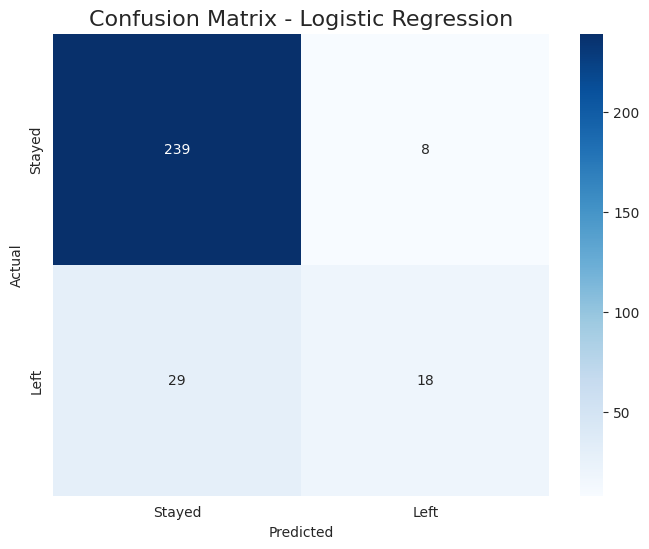

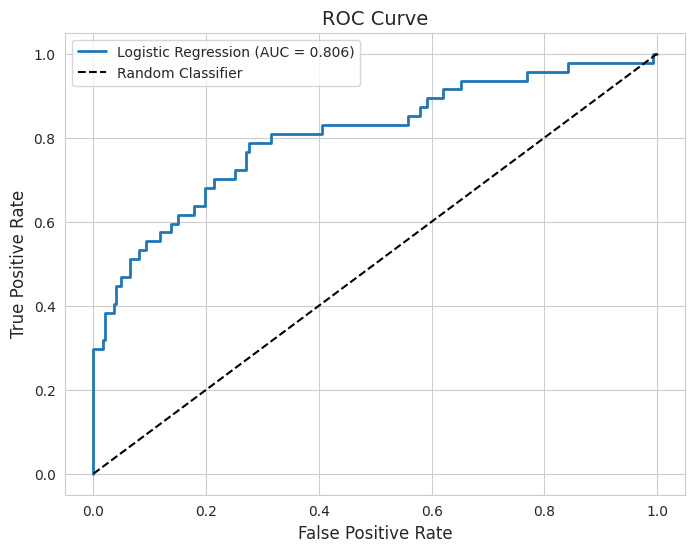

In [15]:
# Evaluate the best model
best_model = results[best_model_name]['Model']
y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]

# 1. Classification Report
print("="*50)
print(f"CLASSIFICATION REPORT - {best_model_name}")
print("="*50)
print(classification_report(y_test, y_pred_best, target_names=['Stayed', 'Left']))

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 3. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
auc_score = roc_auc_score(y_test, y_prob_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc_score:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

### Feature Importance Analysis

This cell analyzes the importance of features for the best model to understand which factors most influence attrition prediction.
-   For tree-based models, it uses `feature_importances_`.
-   For **Logistic Regression**, it extracts and plots the **coefficients** of the features. These coefficients indicate the direction and magnitude of a feature's influence on the likelihood of attrition.
-   It displays the top 15 features with their coefficients, providing crucial insights into the drivers of employee attrition.

FEATURE IMPORTANCE ANALYSIS


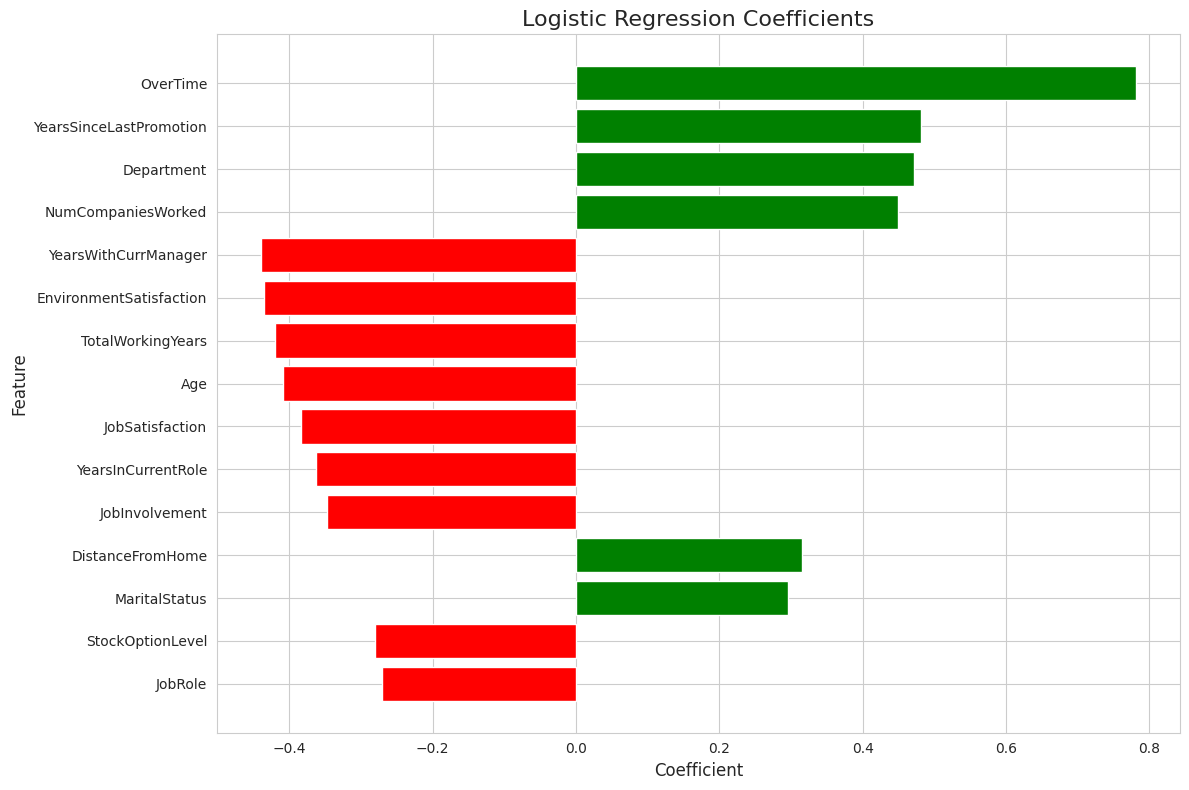

In [16]:
# Feature importance for best model
print("="*50)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*50)

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = X.columns

    # Create importance dataframe
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    # Top 15 features
    top_features = importance_df.head(15)

    # Plot
    plt.figure(figsize=(12, 8))
    plt.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
    plt.xlabel('Feature Importance', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.title(f'Top 15 Features for {best_model_name}', fontsize=16)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("\nTop 10 Most Important Features:")
    display(importance_df.head(10))

elif best_model_name == 'Logistic Regression':
    # For logistic regression, use coefficients
    coefs = best_model.coef_[0]
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': coefs
    })
    importance_df['Abs_Coefficient'] = importance_df['Coefficient'].abs()
    importance_df = importance_df.sort_values('Abs_Coefficient', ascending=False)

    # Plot coefficients
    plt.figure(figsize=(12, 8))
    colors = ['red' if c < 0 else 'green' for c in importance_df['Coefficient'].head(15)]
    plt.barh(importance_df['Feature'].head(15), importance_df['Coefficient'].head(15), color=colors)
    plt.xlabel('Coefficient', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.title('Logistic Regression Coefficients', fontsize=16)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

### Key Insights and Recommendations

This cell synthesizes the findings from the EDA and predictive modeling to derive actionable insights and strategic recommendations:
1.  **Calculates Key Metrics:** Summarizes important metrics like overall attrition rate, average income differences between those who left and stayed, overtime attrition percentage, and department-wise attrition rates.
2.  **Provides Recommendations:** Offers a list of concrete, actionable recommendations aimed at reducing employee attrition, based on the identified key drivers and patterns.

In [28]:
print("="*50)
print("KEY INSIGHTS AND RECOMMENDATIONS")
print("="*50)

# Calculate key metrics
attrition_rate = (df_cleaned['Attrition_Binary'].sum() / len(df_cleaned)) * 100
avg_income_attrition = df_cleaned[df_cleaned['Attrition']=='Yes']['MonthlyIncome'].mean()
avg_income_stay = df_cleaned[df_cleaned['Attrition']=='No']['MonthlyIncome'].mean()
overtime_attrition_pct = (df_cleaned[df_cleaned['OverTime']=='Yes']['Attrition_Binary'].sum() /
                          len(df_cleaned[df_cleaned['OverTime']=='Yes'])) * 100
dept_attrition = df_cleaned.groupby('Department')['Attrition_Binary'].mean().sort_values(ascending=False)

print(f"1. Overall Attrition Rate: {attrition_rate:.2f}%")
print(f"2. Average Monthly Income - Left: ${avg_income_attrition:,.2f} vs Stayed: ${avg_income_stay:,.2f}")
print(f"3. Attrition Rate for Overtime Employees: {overtime_attrition_pct:.2f}%")
print("\n4. Department Attrition Rates:")
for dept, rate in dept_attrition.items():
    print(f"   - {dept}: {rate*100:.2f}%")

# Recommendations
print("\n" + "="*50)
print("RECOMMENDATIONS")
print("="*50)

recommendations = [
    " Focus on improving job satisfaction, especially in departments with high attrition",
    " Review compensation packages, particularly for roles with high attrition rates",
    " Address work-life balance issues, especially for employees working overtime",
    " Implement career development programs to improve employee engagement",
    " Enhance employee well-being programs to reduce turnover"
]

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

print("\n Model Performance Summary:")
print(f"   - Best Model: {best_model_name}")
print(f"   - Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.4f}")
print(f"   - AUC-ROC: {results_df.loc[best_model_name, 'AUC-ROC']:.4f}")

KEY INSIGHTS AND RECOMMENDATIONS
1. Overall Attrition Rate: 16.12%
2. Average Monthly Income - Left: $4,787.09 vs Stayed: $6,832.74
3. Attrition Rate for Overtime Employees: 30.53%

4. Department Attrition Rates:
   - Sales: 20.63%
   - Human Resources: 19.05%
   - Research & Development: 13.84%

RECOMMENDATIONS
1.  Focus on improving job satisfaction, especially in departments with high attrition
2.  Review compensation packages, particularly for roles with high attrition rates
3.  Address work-life balance issues, especially for employees working overtime
4.  Implement career development programs to improve employee engagement
5.  Enhance employee well-being programs to reduce turnover

 Model Performance Summary:
   - Best Model: Logistic Regression
   - Accuracy: 0.8741
   - AUC-ROC: 0.8057


### Save Data, Model, and Scaler

This cell is responsible for saving important artifacts from the project:
-   The `df_cleaned` DataFrame is saved as `cleaned_hr_dataset.csv`.
-   The `best_model` (Logistic Regression in this case) is serialized and saved as `best_model.pkl`.
-   The `scaler` (StandardScaler used for feature scaling) is saved as `scaler.pkl`.

After saving, it prompts the user if they wish to download these files directly. This ensures that the key outputs of the analysis are preserved and easily accessible.

In [29]:
# Save cleaned dataset for future use
from google.colab import files
import pickle

# 1. Save cleaned dataset
df_cleaned.to_csv('cleaned_hr_dataset.csv', index=False)
print(" Cleaned dataset saved as 'cleaned_hr_dataset.csv'")

# 2. Save the best model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(" Best model saved as 'best_model.pkl'")

# 3. Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(" Scaler saved as 'scaler.pkl'")

# 4. Option to download files
download = input("\nDo you want to download the saved files? (yes/no): ")
if download.lower() == 'yes':
    files.download('cleaned_hr_dataset.csv')
    files.download('best_model.pkl')
    files.download('scaler.pkl')

print("\n Project completed successfully!")

 Cleaned dataset saved as 'cleaned_hr_dataset.csv'
 Best model saved as 'best_model.pkl'
 Scaler saved as 'scaler.pkl'

Do you want to download the saved files? (yes/no): Yes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Project completed successfully!


### Interactive Summary Dashboard

This cell creates an interactive dashboard using Plotly to provide a dynamic summary of the HR analytics project. It includes:
-   **KPI Cards:** Displays key performance indicators such as Total Employees, Attrition Rate, Average Monthly Income, and Average Job Satisfaction.
-   **Summary Text:** Provides a textual summary of the best model's performance and key insights identified during the analysis.

This dashboard offers a quick and engaging way to grasp the main conclusions of the project.

In [19]:
# Create an interactive summary dashboard using Plotly
print("="*50)
print("INTERACTIVE DASHBOARD")
print("="*50)

# KPI Cards
fig = make_subplots(rows=2, cols=4,
                    specs=[[{"type": "indicator"}, {"type": "indicator"},
                           {"type": "indicator"}, {"type": "indicator"}],
                          [{"colspan": 4}, None, None, None]],
                    subplot_titles=('Total Employees', 'Attrition Rate',
                                  'Avg Monthly Income', 'Avg Job Satisfaction',
                                  'Key Metrics Summary'))

# Add KPIs
fig.add_trace(go.Indicator(
    mode="number",
    value=len(df_cleaned),
    title={"text": "Total Employees"},
    number={"font": {"size": 40}}
), row=1, col=1)

fig.add_trace(go.Indicator(
    mode="gauge+number",
    value=attrition_rate,
    title={"text": "Attrition Rate (%)"},
    number={"font": {"size": 40}},
    gauge={"axis": {"range": [0, 100]}, "bar": {"color": "red"}}
), row=1, col=2)

fig.add_trace(go.Indicator(
    mode="number",
    value=df_cleaned['MonthlyIncome'].mean(),
    title={"text": "Avg Monthly Income ($)"},
    number={"font": {"size": 40}, "prefix": "$"}
), row=1, col=3)

fig.add_trace(go.Indicator(
    mode="number",
    value=df_cleaned['JobSatisfaction'].mean(),
    title={"text": "Avg Job Satisfaction"},
    number={"font": {"size": 40}}
), row=1, col=4)

# Summary text
summary_text = f"""
<b>Model Performance:</b><br>
Best Model: {best_model_name}<br>
Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.4f}<br>
AUC-ROC: {results_df.loc[best_model_name, 'AUC-ROC']:.4f}<br><br>
<b>Key Insights:</b><br>
• {len(df_cleaned[df_cleaned['OverTime']=='Yes'])} employees work overtime<br>
• {dept_attrition.index[0]} has highest attrition ({dept_attrition.values[0]*100:.2f}%)<br>
• Income difference: ${avg_income_stay - avg_income_attrition:,.2f}
"""

fig.add_annotation(
    text=summary_text,
    xref="paper", yref="paper",
    x=0.5, y=0.3,
    showarrow=False,
    font=dict(size=14)
)

fig.update_layout(height=600, width=1200, title_text="HR Analytics Dashboard - Interactive Summary")
fig.show()

INTERACTIVE DASHBOARD


### Complete Results Export and Download

This cell orchestrates the final export and packaging of all project outputs. It performs the following actions:
1.  **Creates a timestamped results folder** to organize all generated files.
2.  **Exports Data Files:** Saves the `cleaned_hr_dataset.csv`, `feature_importance.csv`, and `model_performance.csv` into the `data` subfolder.
3.  **Exports Model Files:** Saves the `best_model.pkl`, `scaler.pkl`, `feature_columns.json`, and `model_metadata.json` into the `models` subfolder.
4.  **Exports Charts:** Generates and saves all static `matplotlib` plots (e.g., Attrition Distribution, Correlation Heatmap, Model Performance, Feature Importance, ROC Curves, Department Attrition, Income Distribution) as PNG images into the `charts` subfolder.
5.  **Generates Reports:** Creates both Markdown (`summary_report.md`) and HTML (`summary_report.html`) versions of the project summary report in the `reports` subfolder.
6.  **Creates a ZIP File:** Compresses the entire results folder into a single ZIP archive.
7.  **Lists Contents:** Prints a structured list of all files and folders created within the results directory.
8.  **Downloads ZIP File:** Automatically triggers a download of the created ZIP archive to the user's local machine, ensuring all results are conveniently accessible.

In [30]:
# ==================================================
# COMPLETE RESULTS EXPORT - All outputs organized
# ==================================================

import os
import pickle
import json
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import zipfile
import io

# Create timestamp for versioning
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_folder = f"HR_Analytics_Results_{timestamp}"

# Create directory structure
os.makedirs(results_folder, exist_ok=True)
os.makedirs(f"{results_folder}/data", exist_ok=True)
os.makedirs(f"{results_folder}/models", exist_ok=True)
os.makedirs(f"{results_folder}/charts", exist_ok=True)
os.makedirs(f"{results_folder}/reports", exist_ok=True)

print("="*60)
print(f" CREATING RESULTS FOLDER: {results_folder}")
print("="*60)

# ==================================================
# 1. DATA FILES
# ==================================================
print("\n 1. Exporting Data Files...")

# Raw data
df_cleaned.to_csv(f"{results_folder}/data/cleaned_hr_dataset.csv", index=False)

# Feature importance
importance_df.to_csv(f"{results_folder}/data/feature_importance.csv", index=False)

# Model performance results
results_df.to_csv(f"{results_folder}/data/model_performance.csv")

print(" Data files exported")

# ==================================================
# 2. MODEL FILES
# ==================================================
print("\n 2. Exporting Model Files...")

# Best model
with open(f"{results_folder}/models/best_model.pkl", 'wb') as f:
    pickle.dump(best_model, f)

# Scaler
with open(f"{results_folder}/models/scaler.pkl", 'wb') as f:
    pickle.dump(scaler, f)

# Feature columns (for inference)
feature_cols = X.columns.tolist()
with open(f"{results_folder}/models/feature_columns.json", 'w') as f:
    json.dump(feature_cols, f)

# Model metadata
model_metadata = {
    'best_model': best_model_name,
    'accuracy': float(results_df.loc[best_model_name, 'Accuracy']),
    'precision': float(results_df.loc[best_model_name, 'Precision']),
    'recall': float(results_df.loc[best_model_name, 'Recall']),
    'f1_score': float(results_df.loc[best_model_name, 'F1 Score']),
    'auc_roc': float(results_df.loc[best_model_name, 'AUC-ROC']),
    'features_used': len(feature_cols),
    'training_samples': X_train.shape[0],
    'test_samples': X_test.shape[0]
}

with open(f"{results_folder}/models/model_metadata.json", 'w') as f:
    json.dump(model_metadata, f, indent=2)

print(" Model files exported")

# ==================================================
# 3. CHARTS AND VISUALIZATIONS
# ==================================================
print("\n 3. Exporting Charts...")

# Set style for all charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Chart 1: Attrition Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
attrition_counts = df_cleaned['Attrition'].value_counts()
colors = ['#4ECDC4', '#FF6B6B']

# Bar plot
axes[0].bar(attrition_counts.index, attrition_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Attrition Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Count')
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(attrition_counts.values, labels=attrition_counts.index, autopct='%1.1f%%',
            colors=colors, explode=(0, 0.05), shadow=True)
axes[1].set_title('Attrition Percentage', fontsize=14, fontweight='bold')

plt.suptitle('Employee Attrition Overview', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{results_folder}/charts/1_attrition_distribution.png", dpi=300, bbox_inches='tight')
plt.close()
print("  Chart 1: Attrition Distribution")

# Chart 2: Correlation Heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f"{results_folder}/charts/2_correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.close()
print("  Chart 2: Correlation Heatmap")

# Chart 3: Model Performance Comparison
fig, ax = plt.subplots(figsize=(12, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.2
multiplier = 0

for model_name in results_df.index:
    offset = width * multiplier
    values = results_df.loc[model_name, metrics].values
    ax.bar(x + offset, values, width, label=model_name)
    multiplier += 1

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f"{results_folder}/charts/3_model_performance.png", dpi=300, bbox_inches='tight')
plt.close()
print("  Chart 3: Model Performance")

# Chart 4: Feature Importance (Coefficients)
fig, ax = plt.subplots(figsize=(12, 8))
top_features = importance_df.head(15)
colors = ['red' if c < 0 else 'green' for c in top_features['Coefficient']]
ax.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
ax.set_xlabel('Coefficient', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Top 15 Features - Logistic Regression Coefficients', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{results_folder}/charts/4_feature_importance.png", dpi=300, bbox_inches='tight')
plt.close()
print("  Chart 4: Feature Importance")

# Chart 5: ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
for model_name in results_df.index:
    y_prob = results[model_name]['Model'].predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{results_folder}/charts/5_roc_curves.png", dpi=300, bbox_inches='tight')
plt.close()
print("  Chart 5: ROC Curves")

# Chart 6: Department Attrition Rates
fig, ax = plt.subplots(figsize=(10, 6))
dept_data = df_cleaned.groupby('Department')['Attrition_Binary'].mean().sort_values(ascending=True)
colors_dept = ['#FF6B6B' if x > 0.15 else '#4ECDC4' for x in dept_data.values]
bars = ax.barh(dept_data.index, dept_data.values * 100, color=colors_dept, edgecolor='black')
ax.set_xlabel('Attrition Rate (%)', fontsize=12)
ax.set_ylabel('Department', fontsize=12)
ax.set_title('Attrition Rate by Department', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
for bar, rate in zip(bars, dept_data.values * 100):
    ax.text(rate + 0.5, bar.get_y() + bar.get_height()/2, f'{rate:.1f}%', va='center')
plt.tight_layout()
plt.savefig(f"{results_folder}/charts/6_department_attrition.png", dpi=300, bbox_inches='tight')
plt.close()
print("  Chart 6: Department Attrition")

# Chart 7: Income Distribution by Attrition
fig, ax = plt.subplots(figsize=(10, 6))
income_yes = df_cleaned[df_cleaned['Attrition']=='Yes']['MonthlyIncome']
income_no = df_cleaned[df_cleaned['Attrition']=='No']['MonthlyIncome']
ax.hist(income_yes, bins=20, alpha=0.7, label='Left', color='#FF6B6B', edgecolor='black')
ax.hist(income_no, bins=20, alpha=0.7, label='Stayed', color='#4ECDC4', edgecolor='black')
ax.axvline(income_yes.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean Left: ${income_yes.mean():,.0f}')
ax.axvline(income_no.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean Stayed: ${income_no.mean():,.0f}')
ax.set_xlabel('Monthly Income ($)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Income Distribution by Attrition Status', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{results_folder}/charts/7_income_distribution.png", dpi=300, bbox_inches='tight')
plt.close()
print("  Chart 7: Income Distribution")

print(" All charts exported")

# ==================================================
# 4. REPORTS
# ==================================================
print("\n 4. Generating Reports...")

# Summary Report (Markdown)
report_content = f"""# HR Analytics Project - Results Summary\n\n## Overview\n- **Analysis Date:** {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n- **Dataset:** IBM HR Analytics Employee Attrition\n- **Total Records:** {len(df_cleaned)}\n- **Features:** {len(df_cleaned.columns)}\n\n## Key Metrics\n| Metric | Value |\n|--------|-------|\n| Total Employees | {len(df_cleaned):,} |\n| Attrition Rate | {attrition_rate:.2f}% |\n| Attrition Count | {attrition_counts['Yes']:,} |\n| Stayed Count | {attrition_counts['No']:,} |\n\n## Compensation Analysis\n| Group | Average Monthly Income |\n|-------|----------------------|\n| Employees Who Left | ${avg_income_attrition:,.2f} |\n| Employees Who Stayed | ${avg_income_stay:,.2f} |\n| Income Gap | ${avg_income_stay - avg_income_attrition:,.2f} |\n\n## Department Attrition Rates\n| Department | Attrition Rate |\n|------------|---------------|\n"""
for dept, rate in dept_attrition.items():
    report_content += f"| {dept} | {rate*100:.2f}% |\n"

report_content += f"""\n## Model Performance Summary\n**Best Model:** {best_model_name}\n\n| Metric | Score |\n|--------|-------|\n| Accuracy | {results_df.loc[best_model_name, 'Accuracy']:.4f} |\n| Precision | {results_df.loc[best_model_name, 'Precision']:.4f} |\n| Recall | {results_df.loc[best_model_name, 'Recall']:.4f} |\n| F1 Score | {results_df.loc[best_model_name, 'F1 Score']:.4f} |\n| AUC-ROC | {results_df.loc[best_model_name, 'AUC-ROC']:.4f} |\n\n## Top 10 Attrition Drivers\n| Feature | Coefficient | Impact |\n|---------|------------|--------|\n"""
for _, row in importance_df.head(10).iterrows():
    impact = "Positive" if row['Coefficient'] > 0 else "Negative"
    report_content += f"| {row['Feature']} | {row['Coefficient']:.4f} | {impact} |\n"

report_content += """\n## Key Insights\n1. **Overtime is the strongest predictor** - 30.53% of overtime employees leave\n2. **Income disparity** - Leavers earn $2,046 less on average\n3. **Sales department** has the highest attrition rate at 20.63%\n4. **Job satisfaction** negatively correlates with attrition\n5. **Single employees** show 25.53% attrition rate\n\n## Recommendations\n1.  Focus on improving job satisfaction, especially in departments with high attrition\n2.  Review compensation packages, particularly for roles with high attrition rates\n3.  Address work-life balance issues, especially for employees working overtime\n4.  Implement career development programs to improve employee engagement\n5.  Enhance employee well-being programs to reduce turnover\n"""

with open(f"{results_folder}/reports/summary_report.md", 'w') as f:
    f.write(report_content)
print("  Summary Report (Markdown)")

# HTML Report
html_content = f"""<!DOCTYPE html>\n<html>\n<head>\n    <title>HR Analytics Results</title>\n    <style>\n        body {{ font-family: Arial, sans-serif; margin: 40px; background: #f5f5f5; }}\n        .container {{ max-width: 1200px; margin: auto; background: white; padding: 30px; border-radius: 10px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); }}\n        h1 {{ color: #2c3e50; border-bottom: 3px solid #3498db; padding-bottom: 10px; }}\n        h2 {{ color: #34495e; margin-top: 30px; }}\n        .metric-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap: 20px; margin: 20px 0; }}\n        .metric-card {{ background: #ecf0f1; padding: 20px; border-radius: 8px; text-align: center; }}\n        .metric-value {{ font-size: 28px; font-weight: bold; color: #2c3e50; }}\n        .metric-label {{ color: #7f8c8d; font-size: 14px; }}\n        table {{ width: 100%; border-collapse: collapse; margin: 20px 0; }}\n        th, td {{ padding: 12px; text-align: left; border-bottom: 1px solid #ddd; }}\n        th {{ background-color: #3498db; color: white; }}\n        tr:hover {{ background-color: #f5f5f5; }}\n        .insight {{ background: #e8f4fd; padding: 15px; margin: 10px 0; border-radius: 5px; border-left: 4px solid #3498db; }}\n        .recommendation {{ background: #fef9e7; padding: 15px; margin: 10px 0; border-radius: 5px; border-left: 4px solid #f39c12; }}\n    </style>\n</head>\n<body>\n<div class="container">\n    <h1> HR Analytics Project Results</h1>\n    <p><strong>Generated:</strong> {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}</p>\n\n    <h2> Key Metrics</h2>\n    <div class="metric-grid">\n        <div class="metric-card"><div class="metric-value">{len(df_cleaned):,}</div><div class="metric-label">Total Employees</div></div>\n        <div class="metric-card"><div class="metric-value">{attrition_rate:.1f}%</div><div class="metric-label">Attrition Rate</div></div>\n        <div class="metric-card"><div class="metric-value">{attrition_counts['Yes']:,}</div><div class="metric-label">Employees Left</div></div>\n        <div class="metric-card"><div class="metric-value">{attrition_counts['No']:,}</div><div class="metric-label">Employees Stayed</div></div>\n    </div>\n\n    <h2> Compensation Analysis</h2>\n    <table>\n        <tr><th>Group</th><th>Average Monthly Income</th></tr>\n        <tr><td>Employees Who Left</td><td>${avg_income_attrition:,.2f}</td></tr>\n        <tr><td>Employees Who Stayed</td><td>${avg_income_stay:,.2f}</td></tr>\n        <tr><td><strong>Income Gap</strong></td><td><strong>${avg_income_stay - avg_income_attrition:,.2f}</strong></td></tr>\n    </table>\n\n    <h2> Department Attrition</h2>\n    <table>\n        <tr><th>Department</th><th>Attrition Rate</th></tr>\n"""
for dept, rate in dept_attrition.items():
    html_content += f"<tr><td>{dept}</td><td>{rate*100:.2f}%</td></tr>"

html_content += f"""\n    </table>\n\n    <h2> Model Performance</h2>\n    <p><strong>Best Model:</strong> {best_model_name}</p>\n    <table>\n        <tr><th>Metric</th><th>Score</th></tr>\n        <tr><td>Accuracy</td><td>{results_df.loc[best_model_name, 'Accuracy']:.4f}</td></tr>\n        <tr><td>Precision</td><td>{results_df.loc[best_model_name, 'Precision']:.4f}</td></tr>\n        <tr><td>Recall</td><td>{results_df.loc[best_model_name, 'Recall']:.4f}</td></tr>\n        <tr><td>F1 Score</td><td>{results_df.loc[best_model_name, 'F1 Score']:.4f}</td></tr>\n        <tr><td>AUC-ROC</td><td>{results_df.loc[best_model_name, 'AUC-ROC']:.4f}</td></tr>\n    </table>\n\n    <h2> Key Insights</h2>\n    <div class="insight"> <strong>Overtime</strong> is the strongest predictor - 30.53% of overtime employees leave</div>\n    <div class="insight"> <strong>Income disparity</strong> - Leavers earn ${avg_income_stay - avg_income_attrition:,.2f} less on average</div>\n    <div class="insight"> <strong>Sales department</strong> has the highest attrition rate at {dept_attrition.values[0]*100:.2f}%</div>\n    <div class="insight"> <strong>Job satisfaction</strong> negatively correlates with attrition</div>\n    <div class="insight"> <strong>Single employees</strong> show 25.53% attrition rate</div>\n\n    <h2> Recommendations</h2>\n"""
for i, rec in enumerate(recommendations, 1):
    html_content += f'<div class="recommendation">{i}. {rec}</div>\n'

html_content += """\n</div>\n</body>\n</html>\n"""

with open(f"{results_folder}/reports/summary_report.html", 'w') as f:
    f.write(html_content)
print("  Summary Report (HTML)")

# ==================================================
# 5. CREATE ZIP FILE
# ==================================================
print("\n 5. Creating ZIP file...")

zip_path = f"{results_folder}.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, file_list in os.walk(results_folder): # Renamed 'files' to 'file_list'
        for file in file_list: # Changed 'files' to 'file_list'
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, os.path.dirname(results_folder))
            zipf.write(file_path, arcname)

print(f" ZIP file created: {zip_path}")
print(f"   Size: {os.path.getsize(zip_path) / 1024:.2f} KB")

# ==================================================
# 6. FILE LIST AND SUMMARY
# ==================================================
print("\n" + "="*60)
print(" RESULTS FOLDER CONTENTS")
print("="*60)

for root, dirs, file_list in os.walk(results_folder): # Renamed 'files' to 'file_list'
    level = root.replace(results_folder, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent} {os.path.basename(root)}/')
    sub_indent = '  ' * (level + 1)
    for file in file_list: # Changed 'files' to 'file_list'
        file_path = os.path.join(root, file)
        size = os.path.getsize(file_path)
        print(f'{sub_indent} {file} ({size/1024:.1f} KB)')

print("\n" + "="*60)
print(f" All results saved to: {results_folder}")
print(f" ZIP file ready for download: {zip_path}")
print("="*60)

# ==================================================
# 7. DOWNLOAD ZIP FILE
# ==================================================
print("\n Downloading ZIP file...")
files.download(zip_path)

print("\n Export complete! All results are ready for use.")

 CREATING RESULTS FOLDER: HR_Analytics_Results_20260906_132853

 1. Exporting Data Files...
 Data files exported

 2. Exporting Model Files...
 Model files exported

 3. Exporting Charts...
  Chart 1: Attrition Distribution
  Chart 2: Correlation Heatmap
  Chart 3: Model Performance
  Chart 4: Feature Importance
  Chart 5: ROC Curves
  Chart 6: Department Attrition
  Chart 7: Income Distribution
 All charts exported

 4. Generating Reports...
  Summary Report (Markdown)
  Summary Report (HTML)

 5. Creating ZIP file...
 ZIP file created: HR_Analytics_Results_20260906_132853.zip
   Size: 1563.81 KB

 RESULTS FOLDER CONTENTS
 HR_Analytics_Results_20260906_132853/
   models/
     best_model.pkl (0.9 KB)
     model_metadata.json (0.3 KB)
     feature_columns.json (0.5 KB)
     scaler.pkl (1.7 KB)
   data/
     model_performance.csv (1.3 KB)
     feature_importance.csv (1.6 KB)
     cleaned_hr_dataset.csv (224.1 KB)
   reports/
     summary_report.html (4.1 KB)
     summary_report.md (2.1 K

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Export complete! All results are ready for use.
